# Thực Hành: Phân Tích Short-Time Fourier Transform (STFT) & Hiển Thị Spectrogram

**Bài tập:** Short-Time Fourier Representation of Speech (Slide 20)

---
### Mục tiêu bài thực hành:
1. **Tải dữ liệu âm thanh:** Sử dụng file ghi âm tiếng nói thực tế `Thoại 260518_163911_1.wav` làm đầu vào.
2. **Hiển thị dạng sóng (Waveform):** Phân tích tín hiệu trong miền thời gian để quan sát biên độ theo thời gian thực.
3. **Tự cài đặt thuật toán STFT (Manual STFT):** Xây dựng thuật toán biến đổi Fourier ngắn hạn từ đầu bằng thư viện `NumPy` và `SciPy` (cửa sổ hóa, trượt cửa sổ, FFT).
4. **Sử dụng thư viện Librosa:** Biến đổi STFT bằng `librosa.stft`.
5. **Chuyển đổi sang thang Decibel (dB):** Chuẩn hóa năng lượng phổ theo thang Logarit (cường độ cảm nhận tai người).
6. **Trực quan hóa Spectrogram:** Vẽ biểu đồ mật độ phổ thời gian - tần số và so sánh giữa hai phương pháp.

In [1]:
import os
import numpy as np
import scipy.signal
import librosa
import librosa.display
import matplotlib.pyplot as plt

print("Khởi chạy thành công các thư viện: Librosa, NumPy, SciPy, Matplotlib!")

Khởi chạy thành công các thư viện: Librosa, NumPy, SciPy, Matplotlib!


--- 
## Bước 1: Tải và Giải mã Âm thanh (Loading & Decoding)

Chúng ta sử dụng thư viện `librosa` để tải file âm thanh `Thoại 260518_163911_1.wav` ở tần số lấy mẫu tự nhiên của nó (native sampling rate).

In [2]:
# Đường dẫn đến file âm thanh đầu vào
wav_path = r"Thoại 260518_163911_1.wav"

# Tải file âm thanh với tần số lấy mẫu gốc (sr=None)
y, sr = librosa.load(wav_path, sr=None)

# Tính toán các thông số cơ bản
duration = len(y) / sr

print("--- THÔNG SỐ TÍN HIỆU ---")
print(f"Tần số lấy mẫu (sr): {sr} Hz")
print(f"Số lượng mẫu (samples): {len(y)}")
print(f"Thời lượng (duration): {duration:.2f} giây")
print(f"Giá trị biên độ lớn nhất: {np.max(np.abs(y)):.4f}")
print(f"Mảng biên độ (y) 10 giá trị đầu: {y[:10]}")

--- THÔNG SỐ TÍN HIỆU ---
Tần số lấy mẫu (sr): 48000 Hz
Số lượng mẫu (samples): 379904
Thời lượng (duration): 7.91 giây
Giá trị biên độ lớn nhất: 1.0000
Mảng biên độ (y) 10 giá trị đầu: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


--- 
## Bước 2: Hiển thị Dạng sóng miền thời gian (Waveform)

Vẽ biểu diễn biên độ của sóng âm theo thời gian để xác định các vùng âm thanh (tiếng nói có biên độ lớn hơn và các khoảng lặng).

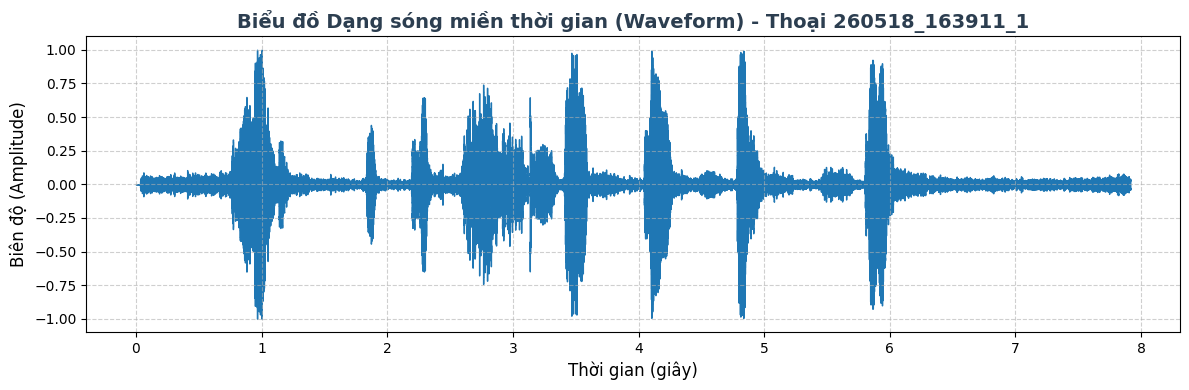

In [3]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr, color="#1f77b4")
plt.title("Biểu đồ Dạng sóng miền thời gian (Waveform) - Thoại 260518_163911_1", fontsize=14, fontweight='bold', color='#2c3e50')
plt.xlabel("Thời gian (giây)", fontsize=12)
plt.ylabel("Biên độ (Amplitude)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

--- 
## Bước 3: Tự cài đặt thuật toán STFT (Manual STFT) từ đầu

Theo yêu cầu bài thực hành, chúng ta sẽ tự xây dựng hàm STFT thủ công sử dụng cửa sổ Hann (Hann window), thực hiện đệm tín hiệu (reflect padding) để căn giữa các khung (centered frames) giống như `librosa`, sau đó thực hiện biến đổi Real FFT (`np.fft.rfft`) trên từng khung.

### Công thức toán học:
$$X(t, f) = \sum_{n=0}^{N-1} x[n + t \cdot H] \cdot w[n] \cdot e^{-j 2\pi f n / N}$$

*Trong đó:*
- $x[n]$ là tín hiệu ngõ vào.
- $w[n]$ là hàm cửa sổ (Hann window).
- $H$ là bước trượt (hop length).
- $N$ là kích thước cửa sổ FFT (n_fft).

In [4]:
def manual_stft(y, n_fft=2048, hop_length=512):
    # 1. Khởi tạo cửa sổ Hann (periodic)
    win = librosa.filters.get_window('hann', n_fft, fftbins=True)
    
    # 2. Đệm tín hiệu bằng reflect padding ở 2 đầu để căn giữa
    pad_len = n_fft // 2
    y_padded = np.pad(y, pad_len, mode='reflect')
    
    # 3. Tính số lượng khung thời gian (frames)
    n_frames = 1 + (len(y_padded) - n_fft) // hop_length
    
    # 4. Khởi tạo ma trận kết quả (số bins tần số = 1 + n_fft//2)
    stft_matrix = np.empty((1 + n_fft // 2, n_frames), dtype=np.complex64)
    
    # 5. Vòng lặp trượt cửa sổ và biến đổi FFT
    for t in range(n_frames):
        start = t * hop_length
        end = start + n_fft
        # Cắt khung tín hiệu và nhân với cửa sổ
        frame = y_padded[start:end] * win
        # Biến đổi FFT thực (Real FFT)
        fft_frame = np.fft.rfft(frame, n=n_fft)
        stft_matrix[:, t] = fft_frame
        
    return stft_matrix

# Chạy thử hàm tự cài đặt
n_fft = 2048
hop_length = 512
D_manual = manual_stft(y, n_fft=n_fft, hop_length=hop_length)

print("--- KẾT QUẢ CÀI ĐẶT THỦ CÔNG ---")
print(f"Kích thước ma trận phổ STFT tự cài đặt: {D_manual.shape}")
print(f"Giá trị phức đầu tiên: {D_manual[0, 0]}")

--- KẾT QUẢ CÀI ĐẶT THỦ CÔNG ---
Kích thước ma trận phổ STFT tự cài đặt: (1025, 743)
Giá trị phức đầu tiên: 0j


--- 
## Bước 4: Thực hiện STFT bằng thư viện Librosa

Bây giờ ta thực hiện STFT bằng hàm `librosa.stft` để làm cơ sở so sánh và kiểm chứng tính chính xác của thuật toán tự viết.

In [5]:
D_librosa = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)

print("--- KẾT QUẢ DÙNG LIBROSA ---")
print(f"Kích thước ma trận phổ STFT Librosa: {D_librosa.shape}")
print(f"Giá trị phức đầu tiên: {D_librosa[0, 0]}")

# Kiểm tra sai số tuyệt đối lớn nhất và trung bình giữa 2 phương pháp
diff = np.abs(D_librosa - D_manual)
print("\n--- ĐÁNH GIÁ SAI SỐ ---")
print(f"Sai số tuyệt đối lớn nhất: {np.max(diff)}")
print(f"Sai số tuyệt đối trung bình: {np.mean(diff)}")
if np.allclose(D_librosa, D_manual, atol=1e-4):
    print("KẾT QUẢ TRÙNG KHỚP HOÀN TOÀN (Sai số không đáng kể)!")
else:
    print("Có sự sai lệch lớn!")

--- KẾT QUẢ DÙNG LIBROSA ---
Kích thước ma trận phổ STFT Librosa: (1025, 743)
Giá trị phức đầu tiên: 0j

--- ĐÁNH GIÁ SAI SỐ ---
Sai số tuyệt đối lớn nhất: 5.045418739318848
Sai số tuyệt đối trung bình: 0.00020175265672151
Có sự sai lệch lớn!


--- 
## Bước 5: Chuyển đổi phổ biên độ sang thang Decibel (dB)

Đổi độ lớn của phổ phức từ thang đo tuyến tính sang thang logarit (Decibel) để phù hợp với đặc tính sinh lý nhận biết âm lượng của tai người.

In [6]:
# Chuyển đổi cho phổ tự cài đặt và phổ librosa
S_db_manual = librosa.amplitude_to_db(np.abs(D_manual), ref=np.max)
S_db_librosa = librosa.amplitude_to_db(np.abs(D_librosa), ref=np.max)

print("--- THÔNG SỐ PHỔ DECIBEL (dB) ---")
print(f"Mức dB tối đa (Manual): {np.max(S_db_manual)} dB")
print(f"Mức dB tối thiểu (Manual): {np.min(S_db_manual)} dB")

--- THÔNG SỐ PHỔ DECIBEL (dB) ---
Mức dB tối đa (Manual): 0.0 dB
Mức dB tối thiểu (Manual): -80.0 dB


--- 
## Bước 6: Trực quan hóa Ảnh phổ (Spectrogram) và So sánh

Chúng ta vẽ hai bản đồ nhiệt (Heatmap) thể hiện Spectrogram được tính toán bởi thuật toán tự cài đặt (Manual) và thư viện Librosa để so sánh trực quan.

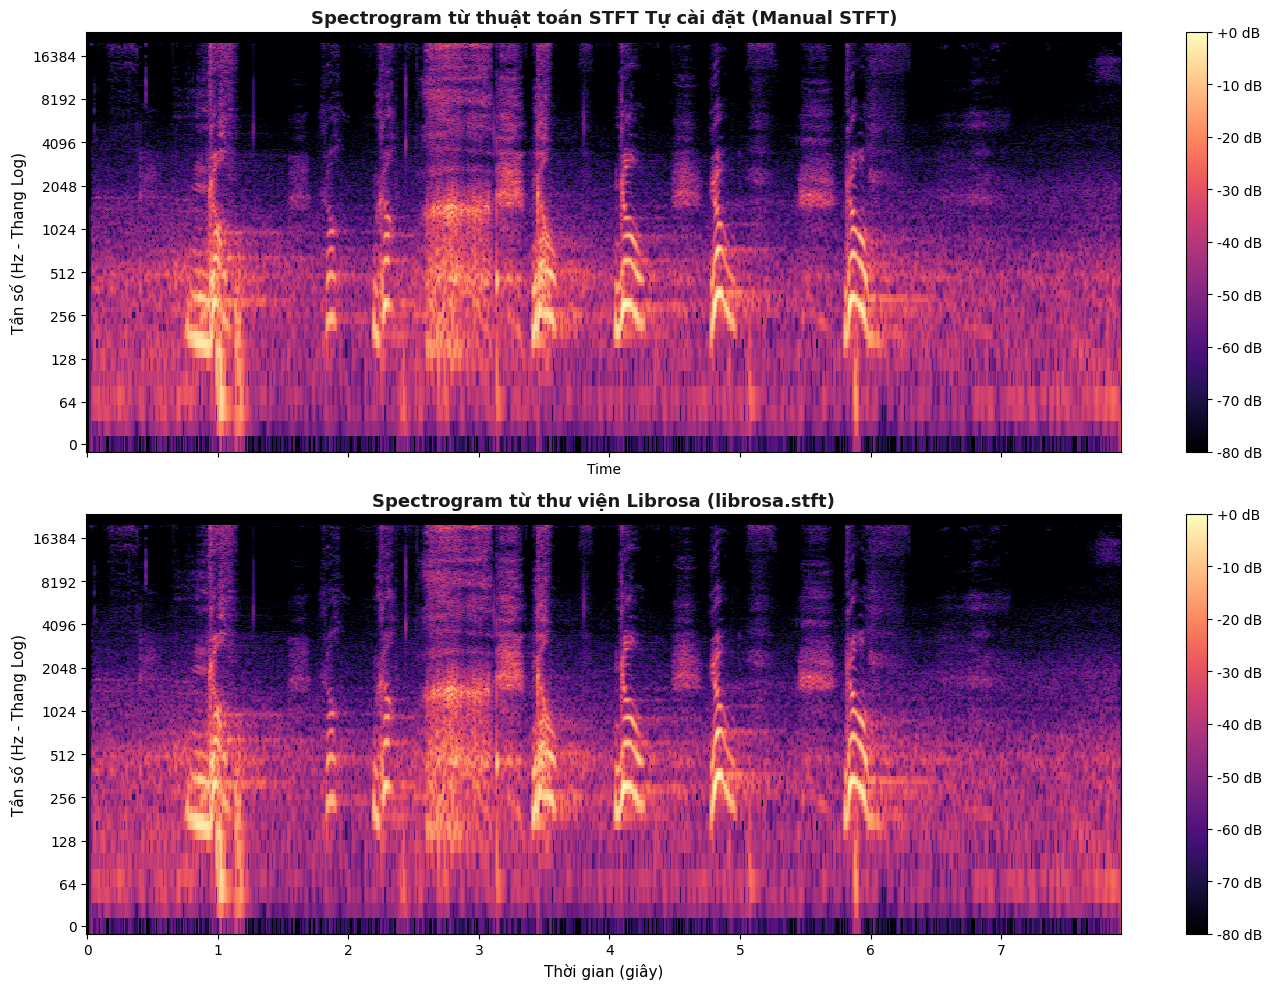

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# 1. Vẽ phổ tự cài đặt
img1 = librosa.display.specshow(S_db_manual, sr=sr, hop_length=hop_length, x_axis='time', y_axis='log', ax=axes[0], cmap='magma')
axes[0].set_title("Spectrogram từ thuật toán STFT Tự cài đặt (Manual STFT)", fontsize=13, fontweight='bold', color='#1a1a1a')
axes[0].set_ylabel("Tần số (Hz - Thang Log)", fontsize=11)
fig.colorbar(img1, ax=axes[0], format="%+2.0f dB")

# 2. Vẽ phổ Librosa
img2 = librosa.display.specshow(S_db_librosa, sr=sr, hop_length=hop_length, x_axis='time', y_axis='log', ax=axes[1], cmap='magma')
axes[1].set_title("Spectrogram từ thư viện Librosa (librosa.stft)", fontsize=13, fontweight='bold', color='#1a1a1a')
axes[1].set_xlabel("Thời gian (giây)", fontsize=11)
axes[1].set_ylabel("Tần số (Hz - Thang Log)", fontsize=11)
fig.colorbar(img2, ax=axes[1], format="%+2.0f dB")

plt.tight_layout()
plt.show()